In [2]:
import os
from pandas import read_csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas import Timestamp
from daesim.utils import ODEModelSolver

from daesim.climate import *
from daesim.plantgrowthphases import PlantGrowthPhases
from daesim.management import ManagementModule
from daesim.plant_1000_thermaltime import PlantModuleCalculator

from daesim2_analysis.parameters import Parameters
from daesim2_analysis.forcing_data import ForcingData
os.chdir('/g/data/xe2/ya6227/NVTAnalysis')
from NVTAnalysis.canola_stage_sampler import CanolaStageSampler
from os.path import exists
from pandas import Timestamp
from daesim2_analysis.utils import load_df_forcing
from pandas import DataFrame
# from multiprocessing import Pool
from multiprocessing.pool import ThreadPool as Pool
from functools import partial
from daesim2_analysis.experiment import Experiment
from daesim2_analysis.run import update_and_run_model

In [3]:
df_Hyola_Blazer_TT = read_csv('data/selected_10_Hyola_Blazer_TT.csv')

In [5]:
from PaddockTS.query import Query
from daesim2_analysis.daesim_config import DAESIMConfig
from daesim2_analysis.parameters import Parameters
# from PaddockTS.Data.environmental import download_environmental_data
from daesim2_analysis.run import update_attribute, update_attribute_in_phase
from scipy.optimize import differential_evolution

In [6]:
queries: list[Query] = []

In [7]:
for idx, row in df_Hyola_Blazer_TT.iterrows():
    query = Query(
        lat=row['Trial GPS Lat'],
        lon=row['Trial GPS Long'],
        collections=['ga_s2am_ard_3', 'ga_s2bm_ard_3'],
        buffer=0.01,
        bands=[
            'nbart_blue',
            'nbart_green',
            'nbart_red',
            'nbart_red_edge_1',
            'nbart_red_edge_2',
            'nbart_red_edge_3',
            'nbart_nir_1',
            'nbart_nir_2',
            'nbart_swir_2',
            'nbart_swir_3'
        ],
        start_time=date.fromisoformat(row['SowingDate']),
        end_time=date.fromisoformat(row['HarvestDate']),
        out_dir='/g/data/xe2/ya6227/NVTAnalysis/data/DAESim',
        tmp_dir='/g/data/xe2/ya6227/NVTAnalysis/data/DAESim',
        stub=row['TrialCode']
    )
    queries += [query]
    # download_environmental_data(query)

In [8]:
# parameters = Parameters.__from_file__("/g/data/xe2/ya6227/daesim2-analysis/parameters/Fast1.json")

parameters = Parameters(
    paths           = ["PlantDev", "PlantDev"],
    modules         = ["PlantDev", "PlantDev"],
    names           = ["gdd_requirements", "gdd_requirements"],
    units           = ["deg C d", "deg C d"],
    init            = [900, 650],
    min             = [600, 350],
    max             = [1800, 700],
    phase_specific  = [True, True],
    phase           = ["vegetative", "grainfill"]
)

parameters = Parameters.__from_json__(
    {
      "Module Path": ["PlantDev", "PlantDev", "PlantDev", "PlantDev", "PlantDev"],
      "Module": ["PlantDev", "PlantDev", "PlantDev", "PlantDev", "PlantDev"],
      "Name": ["gdd_requirements", "gdd_requirements", "gdd_requirements", "gdd_requirements", "gdd_requirements"],
      "Unit": ["deg C d", "deg C d", "deg C d", "deg C d", "deg C d"],
      "Initial Value": [120, 500, 200, 350, 200],
      "Min": [80, 300, 100, 100, 100],
      "Max": [250, 1000, 500, 500, 500],
      "Phase Specific": [True, True, True, True, True],
      "Phase": ["germination","vegetative", "anthesis", "grainfill", "maturity"]
    }
)

# parameters = Parameters.__from_file__('notebooks/parmaeters.json')

In [9]:
daesim_config = DAESIMConfig.from_json_dict("/g/data/xe2/ya6227/daesim2-analysis/daesim_configs/DAESIM1.json") 

In [10]:
sampler = CanolaStageSampler(
    # mean_fractions=(0.09, 0.36, 0.15, 0.40),  # tweak if you have cultivar priors
    # kappa=30.0,                               # Higher the value, higher the number of times you sample values close to mean
    # min_days=(30, 30, 30, 30),                # minimum days in each stage
    # seed=123                                  
)

In [ ]:
def get_input_data_from_query(query: Query):
    SiteX = ClimateModule(CLatDeg=query.lat,CLonDeg=query.lon,timezone=10)
    ForcingDataX = ForcingData(
        SiteX=SiteX,
        sowing_dates=[Timestamp(query.start_time)],
        harvest_dates=[Timestamp(query.end_time)],
        df=load_df_forcing(f'{query.stub_tmp_dir}/environmental/{query.stub}_DAESim_forcing.csv'),
        df_type='0',
        zero_crossing_indices=[0,1]
    )
    ManagementX = ManagementModule(cropType="Canola", sowingDays=ForcingDataX.sowing_days, harvestDays=ForcingDataX.harvest_days, sowingYears=ForcingDataX.sowing_years, harvestYears=ForcingDataX.harvest_years)
    PlantDevX = PlantGrowthPhases(
        phases=["germination", "vegetative", "anthesis", "grainfill", "maturity"],
        gdd_requirements=[120, 500, 200, 350, 200], #rid this
        vd_requirements=[0, 25, 0, 0, 0], #keep this
        allocation_coeffs=[ #rid this
            [0.2, 0.1, 0.7, 0.0, 0.0],   # Phase 1
            [0.5, 0.1, 0.4, 0.0, 0.0],   # Phase 2
            [0.25, 0.5, 0.25, 0.0, 0.0], # Phase 3
            [0.1, 0.1, 0.1, 0.7, 0.0],   # Phase 4
            [0.1, 0.1, 0.1, 0.7, 0.0]    # Phase 5
        ],
        turnover_rates = [ #rid this
            [0.001, 0.001, 0.001, 0.0, 0.0],  # Phase 1
            [0.01,  0.002, 0.01,  0.0, 0.0],  # Phase 2
            [0.02,  0.002, 0.04,  0.0, 0.0],  # Phase 3
            [0.10,  0.008, 0.10,  0.0, 0.0],  # Phase 4
            [0.50,  0.017, 0.50,  0.0, 0.0]   # Phase 5
        ]    ## Turnover rates per pool and developmental phase (days-1))
    )
    
    PlantX = PlantModuleCalculator(
        Site=SiteX,
        Management=ManagementX,
        PlantDev=PlantDevX,
        GDD_method="linear1",
        GDD_Tbase=0.0,
        GDD_Tupp=25.0,
    )
    # %%
    ## Define the callable calculator that defines the right-hand-side ODE function
    PlantXCalc = PlantX.calculate
    
    input_data = [
        ODEModelSolver,
        PlantX,
        ForcingDataX.time_axis,
        ForcingDataX.inputs,
        ForcingDataX.reset_days,
        ForcingDataX.zero_crossing_indices,
        ForcingDataX.time_nday_f,
        ForcingDataX.time_doy_f,
        ForcingDataX.time_year_f
    ]
    return input_data

In [19]:
def get_target_and_uncertainity_from_query(query: Query):
    observables_names = ["start of vegetative", "start of flowering", "start of grainfill", "harvest"]
    observables_units = ["ordinal day of year", "ordinal day of year", "ordinal day of year", "ordinal day of year"]
    sampler = CanolaStageSampler(seed=123)
    # sampler2 = CanolaWeatherAwareStages(seed=123)
    df=load_df_forcing(f'{query.stub_tmp_dir}/environmental/{query.stub}_DAESim_forcing.csv')
    synthetic_observables_df = sampler.sample(str(query.start_time), str(query.end_time), n=100)
    # synthetic_observables_df = sampler2.extract(df, str(query.start_time), str(query.end_time), n=5)
    observables_values = synthetic_observables_df[['vegetative_start_doy', 'flowering_start_doy', 'grainfill_start_doy', 'harvest_doy']].iloc[0].tolist()
  
    # observables_values = CanolaStageSampler(str(query.start_time), str(query.end_time))
    observables_uncertainty = [5, 5, 5, 5]
    # x = sampler.sample(str(query.start_time), str(query.end_time), n=1)
    target_df = pd.DataFrame({
        "Name": observables_names,
        "Units": observables_units,
        "Values": observables_values,
        "Uncertainty": observables_uncertainty,
    })
    y = target_df["Values"].values
    U_y = target_df["Uncertainty"].values
    return y, U_y, target_df

In [20]:
def run_model_and_get_outputs(Plant, ODEModelSolver, time_axis, forcing_inputs, reset_days, zero_crossing_indices):
    ## Define the callable calculator that defines the right-hand-side ODE function
    PlantCalc = Plant.calculate
    
    Model = ODEModelSolver(calculator=PlantCalc, states_init=[0.0, 0.0], time_start=time_axis[0], log_diagnostics=True)
    
    ## Run the model solver
    res = Model.run(
        time_axis=time_axis,
        forcing_inputs=forcing_inputs,
        solver="euler",
        zero_crossing_indices=zero_crossing_indices,
        reset_days=reset_days,
    )

    # Convert the defaultdict to a regular dictionary
    _diagnostics = dict(Model.diagnostics)
    diagnostics = {key: np.array(value) for key, value in _diagnostics.items()}

    # Convert the array to a numeric type, handling mixed int and float types
    diagnostics['idevphase_numeric'] = np.array(diagnostics['idevphase'],dtype=np.float64)
    
    # In the model idevphase can equal None but that is not useable in post-processing, so we set None values to np.nan
    diagnostics["idevphase_numeric"][diagnostics["idevphase"] == None] = np.nan

    # Add np.nan to the end of each array in the dictionary to represent the last time point in the time_axis (corresponds to the last time point of the state vector)
    for key in diagnostics:
        if key == "t":
            diagnostics[key] = np.append(diagnostics[key], res["t"][-1])
        else:
            diagnostics[key] = np.append(diagnostics[key], np.nan)

    # Add state variables to the diagnostics dictionary
    diagnostics["GDD"] = res["y"][0,:]
    diagnostics["VD"] = res["y"][1,:]

    # Add forcing inputs to diagnostics dictionary
    for i,f in enumerate(forcing_inputs):
        ni = i+1
        if f(time_axis[0]).size == 1:
            fstr = f"forcing {ni:02}"
            diagnostics[fstr] = f(time_axis)
        elif f(time_axis[0]).size > 1:
            # this forcing input has levels/layers (e.g. multilayer soil moisture)
            nz = f(time_axis[0]).size
            for iz in range(nz):
                fstr = f"forcing {ni:02} z{iz}"
                diagnostics[fstr] = f(time_axis)[:,iz]
    
    # Observation Operator
    # Calculate model-equivalent observations from model run output

    # # Diagnose time indexes when developmental phase transitions occur
    ngrowing_seasons = (len(Plant.Management.sowingDays) if (isinstance(Plant.Management.sowingDays, int) == False) else 1)
    if ngrowing_seasons > 1:
        # print("Multiple sowing and harvest events occur. Only returning results for first growing season.")
        ## ignore any time steps before first sowing event and after last harvest event
        it_sowing = np.where(time_axis == reset_days[0])[0][0]  #sowing_steps_itax[0]
        
        if Plant.Management.harvestDays is not None:
            it_harvest = np.where(time_axis == reset_days[1])[0][0]  #harvest_steps_itax[0]   # np.where(np.floor(Climate_doy_f(time_axis)) == Plant.Management.harvestDay)[0][0]
        else:
            it_harvest = -1   # if there is no harvest day specified, we just take the last day of the simulation. 
    else:
        # print("Just one sowing event and one harvest event occurs. Returning results for first (and only) growing season.")
        ## ignore any time steps before first sowing event and after last harvest event
        it_sowing = np.where(time_axis == reset_days[0])[0][0]  #sowing_steps_itax[0]
        
        if Plant.Management.harvestDays is not None:
            it_harvest = np.where(time_axis == reset_days[1])[0][0]  #harvest_steps_itax[0]   # np.where(np.floor(Climate_doy_f(time_axis)) == Plant.Management.harvestDay)[0][0]
        else:
            it_harvest = -1   # if there is no harvest day specified, we just take the last day of the simulation. 

    # Diagnose time indexes when developmental phase transitions occur

    # Convert the array to a numeric type, handling mixed int and float types
    idevphase = diagnostics["idevphase_numeric"]   #[it_sowing:it_harvest+1]
    valid_mask = ~np.isnan(idevphase)
    
    # Identify all transitions (number-to-NaN, NaN-to-number, or number-to-different-number)
    it_phase_transitions = np.where(
        ~valid_mask[:-1] & valid_mask[1:] |  # NaN-to-number
        valid_mask[:-1] & ~valid_mask[1:] |  # Number-to-NaN
        (valid_mask[:-1] & valid_mask[1:] & (np.diff(idevphase) != 0))  # Number-to-different-number
    )[0] + 1
    
    # Time index for the end of the maturity phase
    if Plant.PlantDev.phases.index('maturity') in idevphase:
        it_mature = np.where(idevphase == Plant.PlantDev.phases.index('maturity'))[0][-1]    # Index for end of maturity phase
    elif Plant.Management.harvestDays is not None: 
        it_mature = it_harvest    # Maturity developmental phase not completed, so take harvest as the end of growing season
    else:
        it_mature = -1    # if there is no harvest day specified, we just take the last day of the simulation. 

    # it_sowing = np.where(time_axis == Plant.Management.sowingDay)[0][0]
    # if Plant.Management.harvestDay is not None:
    #     it_harvest = np.where(time_axis == Plant.Management.harvestDay)[0][0]
    # else:
    #     it_harvest = -1   # if there is no harvest day specified, we just take the last day of the simulation. 

    # # Convert the array to a numeric type, handling mixed int and float types
    # idevphase = diagnostics["idevphase_numeric"]
    # valid_mask = ~np.isnan(idevphase)
    
    # # Identify all transitions (number-to-NaN, NaN-to-number, or number-to-different-number)
    # it_phase_transitions = np.where(
    #     ~valid_mask[:-1] & valid_mask[1:] |  # NaN-to-number
    #     valid_mask[:-1] & ~valid_mask[1:] |  # Number-to-NaN
    #     (valid_mask[:-1] & valid_mask[1:] & (np.diff(idevphase) != 0))  # Number-to-different-number
    # )[0] + 1
    
    # # Time index for the end of the maturity phase
    # if Plant.PlantDev.phases.index('maturity') in idevphase:
    #     it_mature = np.where(idevphase == Plant.PlantDev.phases.index('maturity'))[0][-1]    # Index for end of maturity phase
    # elif Plant.Management.harvestDay is not None: 
    #     it_mature = it_harvest    # Maturity developmental phase not completed, so take harvest as the end of growing season
    # else:
    #     it_mature = -1    # if there is no harvest day specified, we just take the last day of the simulation. 

    # import pdb; pdb.set_trace()
    # Filter out transitions that occur on or before the sowing day
    # it_phase_transitions = [t for t in it_phase_transitions if time_axis[t] > time_axis[it_sowing+1]]
    it_phase_transitions = [t for t in it_phase_transitions if t > int(it_sowing+1)]
    # Filter out transitions that occur after the maturity or harvest day
    # it_phase_transitions = [t for t in it_phase_transitions if time_axis[t] <= time_axis[it_mature]]
    it_phase_transitions = [t for t in it_phase_transitions if t <= it_mature]

    # Developmental phase indexes
    igermination = Plant.PlantDev.phases.index("germination")
    ivegetative = Plant.PlantDev.phases.index("vegetative")
    if Plant.Management.cropType == "Wheat":
        ispike = Plant.PlantDev.phases.index("spike")
    ianthesis = Plant.PlantDev.phases.index("anthesis")
    igrainfill = Plant.PlantDev.phases.index("grainfill")
    imaturity = Plant.PlantDev.phases.index("maturity")

    ip = np.where(diagnostics['idevphase'][it_phase_transitions] == Plant.PlantDev.phases.index('vegetative'))[0][0]
    tdoy_vegetative = time_axis[it_phase_transitions[ip]]   # ordinal day-of-year at transition point into vegetative phase
    if Plant.PlantDev.phases.index('anthesis') in idevphase[it_sowing+1:it_harvest+1]:
        ip = np.where(diagnostics['idevphase'][it_phase_transitions] == Plant.PlantDev.phases.index('anthesis'))[0][0]
        tdoy_anth0 = time_axis[it_phase_transitions[ip]]   # ordinal day-of-year at transition point into anthesis phase
    else:
        tdoy_anth0 = time_axis[it_harvest]
    if Plant.PlantDev.phases.index('grainfill') in idevphase[it_sowing+1:it_harvest+1]:
        ip = np.where(diagnostics['idevphase'][it_phase_transitions] == Plant.PlantDev.phases.index('grainfill'))[0][0]
        tdoy_anth1 = time_axis[it_phase_transitions[ip]]   # ordinal day-of-year at transition point into grainfill stage (out of anthesis phase)
    else:
        tdoy_anth1 = time_axis[it_harvest]
    tdoy_harvest = time_axis[it_harvest]   # ordinal day-of-year at harvest
    
    # import pdb; pdb.set_trace()
    # Model output (of observables) given the parameter vector p
    # - this is the model output that we compare to observations and use to calibrate the parameters
    M_p = np.array([
        tdoy_vegetative, 
        tdoy_anth0, 
        tdoy_anth1,
        tdoy_harvest,
    ])

    return M_p

In [21]:
def model_function(params: np.ndarray, params_info: DataFrame, query: Query):
    input_data = get_input_data_from_query(query)
    ODEModelSolver, model_instance, time_axis, forcing_inputs, reset_days, zero_crossing_indices, time_nday_f, time_doy_f, time_year_f = input_data
    for idx, value in enumerate(params):
        param_name = param_info["Name"].values[idx]
        param_path = param_info["Module Path"].values[idx]
        full_path = f"{param_path}.{param_name}"
        phase_specific = param_info["Phase Specific"].values[idx]
        
        if phase_specific:
            # Handle phase-specific parameters
            phase = param_info["Phase"].values[idx]
            update_attribute_in_phase(model_instance, full_path, value, phase)
        else:
            if (param_name == "sowingDays") or (param_name == "harvestDays"):
                # Update parameters that must be defined as a list type
                update_attribute(model_instance, full_path, [value])
            else:
                # Update regular parameters
                update_attribute(model_instance, full_path, value)

        # Make sure the solver knows about the sowing and harvest dates as well (to reset the state variables like GDD and VD)
        if (param_name == "sowingDays") or (param_name == "harvestDays"):
            # Find value of time_nday_f where time_doy_f == sowingDay and time_year_f == sowingYear.
            sowingDay, sowingYear = model_instance.Management.sowingDays, model_instance.Management.sowingYears
            sowing_nday = time_nday_f[(np.floor(time_doy_f) == sowingDay) & (np.array(time_year_f) == sowingYear)]
            
            # Find value of time_nday_f where time_doy_f == sowingDay and time_year_f == sowingYear.
            harvestDay, harvestYear = model_instance.Management.harvestDays, model_instance.Management.harvestYears
            harvest_nday = time_nday_f[(np.floor(time_doy_f) == harvestDay) & (np.array(time_year_f) == harvestYear)]
            
            # Set reset_days to be the updated sowing and harvest nday
            reset_days = [sowing_nday[0], harvest_nday[0]]
     
    model_output = run_model_and_get_outputs(model_instance, ODEModelSolver, time_axis, forcing_inputs, reset_days, zero_crossing_indices)

    return model_output

In [22]:
def calculate_error_for_one_site(query, int_params, param_info):
    model_outputs = model_function(int_params, param_info, query)
    observations, observations_unc_sigma, _ = get_target_and_uncertainity_from_query(query)
    error = np.mean( ((model_outputs - observations) ** 2) / (observations_unc_sigma**2))
    return error

def objective_function(params: np.ndarray, params_info: DataFrame, queries: list[Query]):
    int_params = np.round(params).astype(int)
    errors = []
    calculate_error = partial(calculate_error_for_one_site, int_params=int_params, param_info=param_info)
    for q in queries:
        model_outputs = model_function(int_params, param_info, query)
        observations, observations_unc_sigma, _ = get_target_and_uncertainity_from_query(query)
        error = np.mean( ((model_outputs - observations) ** 2) / (observations_unc_sigma**2))
        error = calculate_error_for_one_site(q, int_params, param_info)
        errors += [error]

    # with Pool(processes=len(queries)) as pool:
    #      errors += pool.map(calculate_error, queries)
         
    return sum(errors)/len(errors)

In [23]:
param_info = parameters.df
params = parameters.df['Initial Value'].values

In [24]:
error = objective_function(params, param_info, queries)

In [18]:
sampler

CanolaStageSampler(mu_emerg_lag_d=6.0, sd_emerg_lag_d=2.0, veg_min_d=7, veg_max_d=14, sof_mean_d=50.0, sof_sd_d=3.0, sof_min_d=45, sof_max_d=55, gf_min_after_sof_d=12, gf_max_after_sof_d=18, seed=123)

In [362]:
error

6.1739999999999995

In [363]:
param_bounds = list(zip(parameters.df["Min"].values, parameters.df["Max"].values))

In [414]:
result = differential_evolution(
    objective_function,
    bounds = param_bounds,
    args=(parameters.df, [queries[7]]),
    popsize=5,
    tol=0.00,
    maxiter=100,
    workers=-1
)

/g/data/xe2/ya6227/miniconda3/envs/PaddockTSEnv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


In [415]:
result

             message: Optimization terminated successfully.
             success: True
                 fun: 0.0
                   x: [ 2.052e+02  4.924e+02  2.978e+02  1.355e+02
                        3.925e+02]
                 nit: 32
                nfev: 831
          population: [[ 2.052e+02  4.924e+02 ...  1.355e+02  3.925e+02]
                       [ 2.058e+02  4.879e+02 ...  3.784e+02  3.732e+02]
                       ...
                       [ 2.062e+02  4.933e+02 ...  1.423e+02  2.382e+02]
                       [ 2.064e+02  4.932e+02 ...  4.145e+02  3.330e+02]]
 population_energies: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]

In [416]:
optimised_parameters = np.around(np.array(result.x)).astype(int)
for i, p in enumerate(parameters.df["Name"].values):
    print(i,p,' initial =',parameters.df["Initial Value"].values[i],', optimised =',optimised_parameters[i])

0 gdd_requirements  initial = 120 , optimised = 205
1 gdd_requirements  initial = 500 , optimised = 492
2 gdd_requirements  initial = 200 , optimised = 298
3 gdd_requirements  initial = 350 , optimised = 135
4 gdd_requirements  initial = 200 , optimised = 393


In [417]:
param_info

,Module Path,Module,Name,Unit,Initial Value,Min,Max,Phase Specific,Phase
0,PlantDev,PlantDev,gdd_requirements,deg C d,120,80,250,True,germination
1,PlantDev,PlantDev,gdd_requirements,deg C d,500,300,1000,True,vegetative
2,PlantDev,PlantDev,gdd_requirements,deg C d,200,100,500,True,anthesis
3,PlantDev,PlantDev,gdd_requirements,deg C d,350,100,500,True,grainfill
4,PlantDev,PlantDev,gdd_requirements,deg C d,200,100,500,True,maturity


In [418]:
M_x = model_function(optimised_parameters, param_info, queries[7])
M_x0 = model_function(parameters.df['Initial Value'].values, param_info, queries[7])
_, _, target_df = get_target_and_uncertainity_from_query(queries[7])

Text(0, 0.5, 'Ordinal Day of Year')

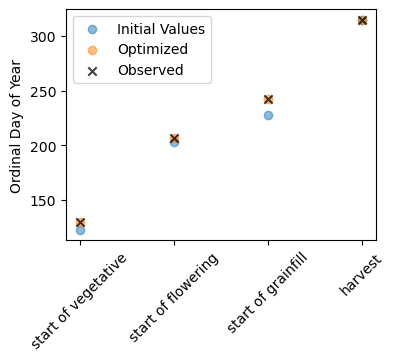

In [419]:
fig, axes = plt.subplots(1,1,figsize=(4,3))

axes.scatter(np.arange(len(target_df)), M_x0, label="Initial Values", color="C0", marker="o", alpha=0.5)
axes.scatter(np.arange(len(target_df)), M_x, label="Optimized", c="C1", marker="o", alpha=0.5)
axes.scatter(np.arange(len(target_df)), target_df['Values'], c='k', marker='x', alpha=0.75, label="Observed")
axes.legend()
axes.set_xticks(np.arange(M_x.size)) 
axes.set_xticklabels(target_df['Name'],rotation=45)
axes.set_ylabel("Ordinal Day of Year")

In [420]:
target_df
#overdetermined problem

,Name,Units,Values,Uncertainty
0,start of vegetative,ordinal day of year,130,5
1,start of flowering,ordinal day of year,207,5
2,start of grainfill,ordinal day of year,242,5
3,harvest,ordinal day of year,315,5


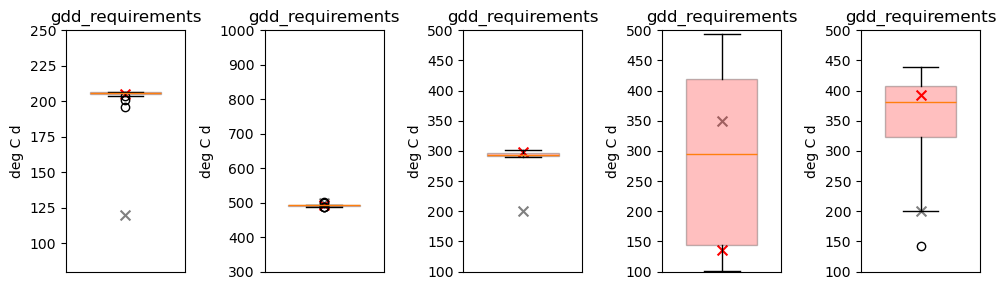

In [421]:
num_params = len(parameters.df)
fig, axes = plt.subplots(1, num_params, figsize=(num_params * 2, 3))

# If only one parameter, axes won't be a list, so handle that case
if num_params == 1:
    axes = [axes]

# Loop over each parameter and create a subplot
for i, ax in enumerate(axes):
    param_name = parameters.df.loc[i, "Name"]
    param_unit = parameters.df.loc[i, "Unit"]
    param_min = parameters.df.loc[i, "Min"]
    param_max = parameters.df.loc[i, "Max"]
    param_init = parameters.df.loc[i, "Initial Value"]
    solution_value = result.x[i]
    param_population = result.population[:,i]

    # Plot the initial value as a scatter point
    ax.scatter([1], [param_init], color='0.5', s=50, marker='x')
    # Plot the solution value as a scatter point
    ax.scatter([1], [solution_value], color='red', s=50, marker='x')
    # Plot the box and whisker plot for the parameter "population"
    bplot = ax.boxplot(param_population, widths=0.6, patch_artist=True, boxprops=dict(facecolor='r', color='k', alpha=0.25))
    
    # Customize the subplot
    ax.set_title(param_name)
    ax.set_ylabel(f'{param_unit}')
    ax.set_ylim(param_min, param_max)
    ax.set_xticks([])  # Remove x-ticks for a cleaner look

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

In [422]:
parameters.to_file("parameters/PlantDevCalibrated.json")

In [25]:
d_fd_mapping = {
    'Climate_solRadswskyb_f': 'forcing 01',
    'Climate_solRadswskyd_f': 'forcing 02',
    'Climate_airTempCMin_f': 'forcing 03',
    'Climate_airTempCMax_f': 'forcing 04',
    'Climate_airPressure_f': 'forcing 05',
    'Climate_airRH_f': 'forcing 06',
    'Climate_airCO2_f': 'forcing 07',
    'Climate_airO2_f': 'forcing 08',
    'Climate_airU_f': 'forcing 09',
    'Climate_soilTheta_z_f': 'forcing 10',
    'Climate_doy_f': 'forcing 11',
    'Climate_year_f': 'forcing 12'
}

In [26]:
experiment = Experiment(
    crop_type='Canola',
    CLatDeg=queries[5].lat,
    CLonDeg=queries[5].lon,
    sowing_dates=[queries[5].start_time],
    harvest_dates=[queries[5].end_time],
    df_forcing=load_df_forcing(f'{queries[5].stub_tmp_dir}/environmental/{queries[5].stub}_DAESim_forcing.csv'),
    xsite='some_query',
    daesim_config='daesim_configs/DAESIM1.json',
    parameters="parameters/PlantDevCalibrated.json"
)

In [27]:
experiment.parameters

Parameters(paths=['PlantDev', 'PlantDev', 'PlantDev', 'PlantDev', 'PlantDev'], modules=['PlantDev', 'PlantDev', 'PlantDev', 'PlantDev', 'PlantDev'], names=['gdd_requirements', 'gdd_requirements', 'gdd_requirements', 'gdd_requirements', 'gdd_requirements'], units=['deg C d', 'deg C d', 'deg C d', 'deg C d', 'deg C d'], init=[120, 500, 200, 350, 200], min=[80, 300, 100, 100, 100], max=[250, 1000, 500, 500, 500], phase_specific=[True, True, True, True, True], phase=['germination', 'vegetative', 'anthesis', 'grainfill', 'maturity'], optimised=None, df=  Module Path    Module              Name     Unit  Initial Value  Min   Max  \
0    PlantDev  PlantDev  gdd_requirements  deg C d            120   80   250   
1    PlantDev  PlantDev  gdd_requirements  deg C d            500  300  1000   
2    PlantDev  PlantDev  gdd_requirements  deg C d            200  100   500   
3    PlantDev  PlantDev  gdd_requirements  deg C d            350  100   500   
4    PlantDev  PlantDev  gdd_requirements  deg

In [426]:
optimised_parameters

array([205, 492, 298, 135, 393])

In [432]:
parameters.df['Initial Value'].tolist()

[120, 500, 200, 350, 200]

In [29]:
parameters: Parameters = experiment.parameters
param_values = parameters.sample(experiment.n_samples)

# %%
# Call the function that updates parameters, runs the model and returns selected outputs
model_output = update_and_run_model(
    # optimised_parameters,
    [205, 492, 298, 135, 393],
    experiment.PlantX,
    experiment.input_data,
    parameters.df,
    parameters.problem
)

/g/data/xe2/ya6227/miniconda3/envs/PaddockTSEnv/lib/python3.10/site-packages/daesim/plantcarbonwater.py:459: RuntimeWarning: divide by zero encountered in divide
  r_ws = (airP/(self.Site.R_w_mol*(leafTempC+273.15)))/gsw    ## converts stomatal conductance (mol H2O m-2 s-1) to stomatal resistance (s m-1)  (see Nobel (2009) Section 8.1F) TODO: Check this and cross-check it with calculations of stomatal resistance in leafgasexchange modules and perhaps also SCOPE model code


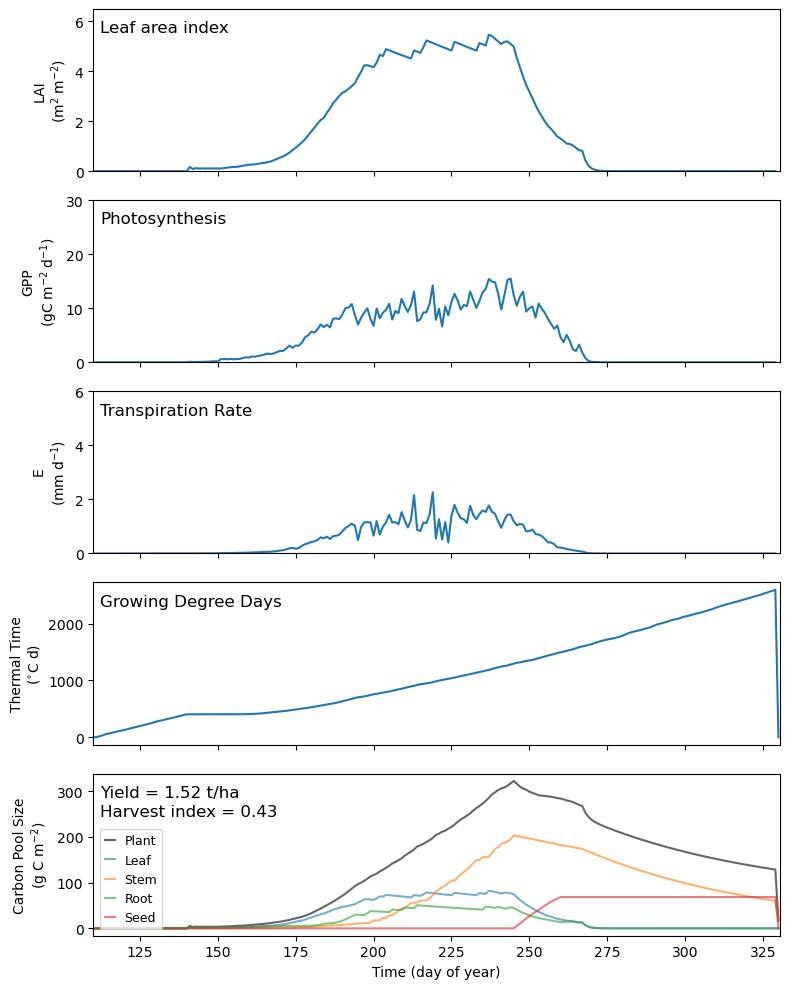

In [30]:
fig, axes = plt.subplots(5,1,figsize=(8,10),sharex=True)
axes[0].plot(model_output['t'], model_output["LAI"])
axes[0].set_ylabel("LAI\n"+r"($\rm m^2 \; m^{-2}$)")
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].annotate("Leaf area index", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[0].set_ylim([0,6.5])

axes[1].plot(model_output["t"], model_output["GPP"])
axes[1].set_ylabel("GPP\n"+r"($\rm g C \; m^{-2} \; d^{-1}$)")
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].annotate("Photosynthesis", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[1].set_ylim([0,30])

axes[2].plot(model_output["t"], model_output["E_mmd"])
axes[2].set_ylabel(r"$\rm E$"+"\n"+r"($\rm mm \; d^{-1}$)")
axes[2].tick_params(axis='x', labelrotation=45)
axes[2].annotate("Transpiration Rate", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[2].set_ylim([0,6])

axes[3].plot(model_output["t"], model_output["Bio_time"])
axes[3].set_ylabel("Thermal Time\n"+r"($\rm ^{\circ}$C d)")
axes[3].annotate("Growing Degree Days", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)

alp = 0.6
axes[4].plot(model_output["t"], model_output["Cleaf"]+model_output["Croot"]+model_output["Cstem"]+model_output["Cseed"],c='k',label="Plant", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cleaf"],label="Leaf", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cstem"],label="Stem", alpha=alp)
axes[4].plot(model_output["t"], model_output["Croot"],label="Root", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cseed"],label="Seed", alpha=alp)
axes[4].set_ylabel("Carbon Pool Size\n"+r"(g C $\rm m^{-2}$)")
axes[4].set_xlabel("Time (day of year)")
axes[4].legend(loc=3,fontsize=9,handlelength=0.8)

# Time indexing for model output data, to determine outputs at specific times in the growing season
itax_sowing, itax_mature, itax_harvest, itax_phase_transitions = experiment.PlantX.Site.time_index_growing_season(experiment.ForcingDataX.time_index, model_output['idevphase_numeric'], experiment.PlantX.Management, experiment.PlantX.PlantDev)
harvest_index_maturity = model_output["Cseed"][itax_harvest] / (model_output["Cleaf"][itax_mature]+model_output["Croot"][itax_mature]+model_output["Cstem"][itax_mature])
yield_from_seed_Cpool = model_output["Cseed"][itax_harvest]/100 * (1/experiment.PlantX.PlantCH2O.f_C)   ## convert gC m-2 to t dry biomass ha-1
axes[4].annotate("Yield = %1.2f t/ha" % (yield_from_seed_Cpool), (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[4].annotate("Harvest index = %1.2f" % (harvest_index_maturity), (0.01,0.81), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[0].set_xlim([experiment.PlantX.Management.sowingDays[0], model_output[d_fd_mapping['Climate_doy_f']][-1]])
plt.tight_layout()

In [411]:
experiment.df_forcing

,Date,Precipitation,Runoff,Minimum temperature,Maximum temperature,Soil moisture,Vegetation growth,Vegetation leaf area,VPeff,Uavg,SRAD,DOY,Year,xsite
0,2023-01-01,0.122220,0.001023,11.86,20.03,315.35434,0.701341,0.55,11.529105,3.203402,20.1,1,2023,CHTA23ST
1,2023-01-02,0.000000,NaN,15.97,20.81,NaN,NaN,NaN,12.867537,4.334432,22.3,2,2023,CHTA23ST
2,2023-01-03,0.000000,NaN,15.72,20.34,NaN,NaN,NaN,13.732695,5.443939,16.4,3,2023,CHTA23ST
3,2023-01-04,0.000000,NaN,14.18,23.45,NaN,NaN,NaN,14.417822,6.443983,27.4,4,2023,CHTA23ST
4,2023-01-05,0.000000,NaN,14.78,25.98,NaN,NaN,NaN,13.763055,5.821664,30.8,5,2023,CHTA23ST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2023-12-27,0.284584,0.006302,14.16,19.74,291.14392,0.033713,0.10,16.252468,6.504871,19.7,361,2023,CHTA23ST
361,2023-12-28,2.115740,NaN,14.48,17.12,NaN,NaN,NaN,13.844392,6.067361,11.7,362,2023,CHTA23ST
362,2023-12-29,1.221129,NaN,15.23,18.22,NaN,NaN,NaN,12.707437,6.411001,14.3,363,2023,CHTA23ST
363,2023-12-30,0.930480,NaN,15.89,18.91,NaN,NaN,NaN,15.215534,5.867371,13.9,364,2023,CHTA23ST


In [412]:
experiment.df_forcing.columns

Index(['Date', 'Precipitation', 'Runoff', 'Minimum temperature',
       'Maximum temperature', 'Soil moisture', 'Vegetation growth',
       'Vegetation leaf area', 'VPeff', 'Uavg', 'SRAD', 'DOY', 'Year',
       'xsite'],
      dtype='object')

In [413]:
import numpy as np
import pandas as pd
from dataclasses import dataclass

# Weather-aware Hyola Blazer TT stage sampler using thermal time (GDD, base 0°C)
# Expects forcing columns:
# ['Date','Precipitation','Runoff','Minimum temperature','Maximum temperature',
#  'Soil moisture','Vegetation growth','Vegetation leaf area','VPeff','Uavg',
#  'SRAD','DOY','Year','xsite']

def _to_ts(x):
    if isinstance(x, pd.Timestamp):
        return x.normalize()
    if isinstance(x, str):
        return pd.Timestamp(x)
    if isinstance(x, np.datetime64):
        return pd.Timestamp(x).normalize()
    raise TypeError("Expected pd.Timestamp or 'YYYY-MM-DD' string.")

def _doy(ts: pd.Timestamp) -> int:
    return int(ts.dayofyear)

def _prepare_forcing(df: pd.DataFrame) -> pd.DataFrame:
    if "Date" not in df.columns:
        raise KeyError("Forcing DataFrame must contain a 'Date' column.")
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"])
    out = out.set_index("Date").sort_index()
    # daily frequency with fill for small gaps
    if out.index.freq is None or out.index.freqstr != "D":
        out = out.asfreq("D")
    return out.ffill().bfill()

def _get_tmean(df: pd.DataFrame) -> pd.Series:
    if "tmean" in df.columns:
        return df["tmean"].astype(float)
    if {"Minimum temperature", "Maximum temperature"}.issubset(df.columns):
        return (df["Minimum temperature"].astype(float) + df["Maximum temperature"].astype(float)) / 2.0
    raise ValueError("Forcing must have 'tmean' OR both 'Minimum temperature' and 'Maximum temperature'.")

def _cum_gdd(tmean: pd.Series, tbase: float = 0.0) -> pd.Series:
    gdd = (tmean - float(tbase)).clip(lower=0.0)
    return gdd.cumsum()

def _trunc_normal(rng, mean: float, sd: float, low: float, high: float) -> float:
    while True:
        x = rng.normal(mean, sd)
        if low <= x <= high:
            return float(x)

def _first_date_crossing(cum: pd.Series, thresh: float) -> pd.Timestamp:
    idx = cum.index[cum >= float(thresh)]
    if len(idx) > 0:
        return idx[0]
    # extrapolate if threshold not reached
    daily = cum.diff().dropna()
    mean_step = float(daily.mean()) if len(daily) else 10.0
    extra = int(np.ceil((float(thresh) - float(cum.iloc[-1])) / max(mean_step, 1e-6)))
    return cum.index[-1] + pd.Timedelta(days=extra)

@dataclass
class CanolaWeatherAwareStages:
    # TT priors (°Cd from EMERGENCE)
    mu_veg_tt: float = 100.0
    sd_veg_tt: float = 40.0

    mu_sof_tt: float = 680.0
    sd_sof_tt: float = 120.0

    mu_gf_delta_tt: float = 180.0
    sd_gf_delta_tt: float = 60.0

    # Emergence lag (days) from sowing
    mu_emerg_lag_d: float = 6.0
    sd_emerg_lag_d: float = 2.0
    min_emerg_lag: float = 0.0
    max_emerg_lag: float = 30.0

    # Base temperature for GDD
    tbase: float = 0.0

    # Optional soft day-based clamps (from emergence)
    apply_day_clamps: bool = True
    sof_min_d: int = 45
    sof_max_d: int = 55
    gf_min_after_sof_d: int = 12
    gf_max_after_sof_d: int = 18

    # RNG seed
    seed: int | None = 123

    def __post_init__(self):
        self.rng = np.random.default_rng(self.seed)

    def _sample_tt_thresholds(self):
        veg = _trunc_normal(self.rng, self.mu_veg_tt, self.sd_veg_tt, low=0.0, high=5000.0)
        sof = _trunc_normal(self.rng, self.mu_sof_tt, self.sd_sof_tt, low=max(veg + 50.0, 200.0), high=6000.0)
        gf  = sof + _trunc_normal(self.rng, self.mu_gf_delta_tt, self.sd_gf_delta_tt, low=60.0, high=800.0)
        return veg, sof, gf

    def _emergence_date(self, sowing: pd.Timestamp) -> tuple[pd.Timestamp, float]:
        lag = _trunc_normal(self.rng, self.mu_emerg_lag_d, self.sd_emerg_lag_d,
                            self.min_emerg_lag, self.max_emerg_lag)
        return sowing + pd.Timedelta(days=int(round(lag))), lag

    def _map_tt_to_dates(self, tmean: pd.Series, Emergence: pd.Timestamp, tt_veg: float, tt_sof: float, tt_gf: float):
        after_em = tmean.loc[Emergence:]
        if len(after_em) == 0:
            # create a simple tail if needed
            idx = pd.date_range(Emergence, Emergence + pd.Timedelta(days=365), freq="D")
            after_em = pd.Series(index=idx, data=tmean.iloc[-1], dtype=float)
        cum = _cum_gdd(after_em, tbase=self.tbase)

        Veg = _first_date_crossing(cum, tt_veg)
        SOF = _first_date_crossing(cum, tt_sof)
        GF  = _first_date_crossing(cum, tt_gf)

        # optional calendar clamps
        if self.apply_day_clamps:
            # Keep SOF ~45–55 d after emergence
            sof_days = (SOF - Emergence).days
            if sof_days < self.sof_min_d:
                SOF = Emergence + pd.Timedelta(days=self.sof_min_d)
            elif sof_days > self.sof_max_d:
                SOF = Emergence + pd.Timedelta(days=self.sof_max_d)
            # Keep GF ~12–18 d after SOF
            gf_days = (GF - SOF).days
            if gf_days < self.gf_min_after_sof_d:
                GF = SOF + pd.Timedelta(days=self.gf_min_after_sof_d)
            elif gf_days > self.gf_max_after_sof_d:
                GF = SOF + pd.Timedelta(days=self.gf_max_after_sof_d)
            # Ensure Veg < SOF
            if Veg >= SOF:
                Veg = SOF - pd.Timedelta(days=1)

        # strict monotonicity
        if not (Emergence < Veg <= SOF <= GF):
            Veg = max(Veg, Emergence + pd.Timedelta(days=1))
            SOF = max(SOF, Veg + pd.Timedelta(days=1))
            GF  = max(GF,  SOF + pd.Timedelta(days=1))

        return Veg, SOF, GF

    def extract(self, forcing_df: pd.DataFrame, sowing, harvest, n: int = 1, as_dataframe: bool = True):
        F = _prepare_forcing(forcing_df)
        tmean = _get_tmean(F)

        S = _to_ts(sowing)
        H = _to_ts(harvest)
        if H <= S:
            H = H + pd.DateOffset(years=1)

        if S < F.index[0]:
            raise ValueError(f"Forcing starts at {F.index[0].date()}, which is after sowing {S.date()}.")

        rows = []
        for _ in range(int(n)):
            Emergence, _ = self._emergence_date(S)
            tt_veg, tt_sof, tt_gf = self._sample_tt_thresholds()

            Veg, SOF, GF = self._map_tt_to_dates(tmean, Emergence, tt_veg, tt_sof, tt_gf)

            # Keep within [Emergence+1, H-1]
            Veg = min(max(Veg, Emergence + pd.Timedelta(days=1)), H - pd.Timedelta(days=3))
            SOF = min(max(SOF, Veg + pd.Timedelta(days=1)), H - pd.Timedelta(days=2))
            GF  = min(max(GF,  SOF + pd.Timedelta(days=1)), H - pd.Timedelta(days=1))

            rows.append(dict(
                sowing_ts=S, harvest_ts=H, emergence_ts=Emergence,
                vegetative_start_ts=Veg, flowering_start_ts=SOF, grainfill_start_ts=GF,
                sowing_doy=_doy(S), harvest_doy=_doy(H), emergence_doy=_doy(Emergence),
                vegetative_start_doy=_doy(Veg), flowering_start_doy=_doy(SOF), grainfill_start_doy=_doy(GF),
            ))

        if as_dataframe:
            return pd.DataFrame(rows)[[
                "sowing_ts","harvest_ts","emergence_ts",
                "vegetative_start_ts","flowering_start_ts","grainfill_start_ts",
                "sowing_doy","harvest_doy","emergence_doy",
                "vegetative_start_doy","flowering_start_doy","grainfill_start_doy",
            ]]
        return rows

# -----------------------------
# Example:
# forcing = your_dataframe  # with the columns listed above
# sampler = CanolaWeatherAwareStages(seed=42, apply_day_clamps=True)
# out = sampler.extract(forcing, sowing="2025-05-05", harvest="2025-09-10", n=5)
# print(out)
# -----------------------------


In [404]:
sampler = CanolaWeatherAwareStages()

In [388]:
sampler.extract(experiment.df_forcing, str(queries[5].start_time), str(queries[5].end_time))

,sowing_ts,harvest_ts,emergence_ts,vegetative_start_ts,flowering_start_ts,grainfill_start_ts,sowing_doy,harvest_doy,emergence_doy,vegetative_start_doy,flowering_start_doy,grainfill_start_doy
0,2023-04-20,2023-11-25,2023-04-24,2023-04-30,2023-06-18,2023-07-06,110,329,114,120,169,187
